In [1]:
import time
notebook_start = time.perf_counter()
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as ticker, sys, os, csv, shutil, json
from scipy.optimize import least_squares
from itertools import chain
from si_units import BAR, KELVIN
from pathlib import Path
from feos.eos import EquationOfState, PhaseDiagram
from feos.pcsaft import PcSaftParameters
from feos.eos.estimator import Estimator, Loss, DataSet, Phase
import io, base64

sys.path.append("..")
import PLOT_SETTINGS as ps

plot_dir = Path("PLOTS")
if plot_dir.exists():
    shutil.rmtree(plot_dir)
plot_dir.mkdir()

mixture = "Ar-CH4"
PLOT    = False
# PLOT    = True
npoints = 1000       # for VLE calculations
nfit    = 1000
# deg     = 2

In [2]:
def eos_from_kij(kij):
    """Returns equation of state (PC-SAFT) for current kij."""
    global parameters
    p = PcSaftParameters.new_binary(parameters.pure_records, kij)
    return EquationOfState.pcsaft(p)

def cost(kij, estimator):
    """Calculates cost function for current parameters."""
    return estimator.cost(eos_from_kij(kij))

def components(mixture):
    global comp1, comp2
    comp1, comp2 = mixture.split("-")
    return comp1, comp2

def poly_to_string(coeffs, var="T", name="k_ij"):
    """
    Build a readable polynomial string from np.polyfit coeffs.
    coeffs are in descending powers: [c_n, ..., c_1, c_0]
    """
    deg     = len(coeffs) - 1
    terms   = []
    for i, coef in enumerate(coeffs):
        power = deg - i
        if power == 0:
            terms.append(f"{coef:.6e}")
        elif power == 1:
            terms.append(f"({coef:.6e})*{var}")
        else:
            terms.append(f"({coef:.6e})*{var}^{power}")
    return f"{name}({var}) = " + " + ".join(terms)

def fit_kij_polynomial(df_best_kij, deg, T_col="Temperature_[K]", kij_col="kij"):
    """
    Fit kij(T) with a polynomial of degree 'deg'.

    Returns:
      coeffs  : np.ndarray of coefficients (descending powers)
      kij_func: np.poly1d callable function
    """
    T_data      = df_best_kij[T_col].to_numpy(dtype=float)
    kij_data    = df_best_kij[kij_col].to_numpy(dtype=float)

    # sort by temperature
    order       = np.argsort(T_data)
    T_data      = T_data[order]
    kij_data    = kij_data[order]

    coeffs      = np.polyfit(T_data, kij_data, deg=deg)
    kij_func    = np.poly1d(coeffs)

    print("\nFitted function:")
    print(poly_to_string(coeffs, var="T", name="k_ij"))
    # print("\nnp.poly1d form:\n", kij_func)

    return coeffs, kij_func, T_data, kij_data

def set_custom_xlabel(ax, fontsize=ps.label_fontsize):
    ax.text(0.33, -0.17, r"$x_{\mathrm{Ar}}$",
        color="blue", fontsize=fontsize,transform=ax.transAxes, ha="right")
    ax.text(0.35, -0.17, r"$,$",
        color="black", fontsize=fontsize,transform=ax.transAxes, ha="center")
    ax.text(0.36, -0.17, r"$y_{\mathrm{Ar}}$",
        color="red", fontsize=fontsize,transform=ax.transAxes, ha="left")
    ax.text(0.49, -0.17, r"$/ \;[{\mathrm{mol} \; \mathrm{mol}^{-1}}]$",
        color="black", fontsize=fontsize,transform=ax.transAxes, ha="left")
    
def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

In [3]:
def VLE_PLOT(mixture, data, cols, temperature, kij):

    comp1, comp2    = components(mixture)
    isotherm        = data[data[cols["T"]] == temperature]
    
    if isotherm.empty:
        raise ValueError(f"No data available for T = {temperature} K")

    fig, ax = ps.plot_init()
    i = 0
 
    # Experimental data
    if isotherm[cols["Comp"]].iloc[0] == comp2:
        ax.plot(1-isotherm[cols["x1"]], isotherm[cols["P"]],
            color='blue', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markerfacecolor="#56abff", markeredgewidth=ps.markeredgewidth,
            label=isotherm.source.iloc[0] + f" (T = {temperature} K)")

        ax.plot(1-isotherm[cols["y1"]], isotherm[cols["P"]],
            color='red', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markerfacecolor="#FF5656", markeredgewidth=ps.markeredgewidth,)
    else:
        ax.plot(isotherm[cols["x1"]], isotherm[cols["P"]],
            color='blue', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize,markerfacecolor="#56abff", markeredgewidth=ps.markeredgewidth,
            label=isotherm.source.iloc[0] + f" (T = {temperature} K)")

        ax.plot(isotherm[cols["y1"]], isotherm[cols["P"]],
            color='red', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markerfacecolor="#FF5656", markeredgewidth=ps.markeredgewidth,)

    # PC-SAFT predictions
    vle = PhaseDiagram.binary_vle(eos_from_kij(kij),temperature * KELVIN, npoints)

    ax.plot(vle.vapor.molefracs[:, 1], vle.vapor.pressure / BAR,
        color='red', linewidth=ps.linewidth, linestyle="-",
        label=fr"PC-SAFT ($k_{{ij}} = {kij:.3f}$)")

    ax.plot(vle.liquid.molefracs[:, 1], vle.liquid.pressure / BAR,
        color='blue', linewidth=ps.linewidth, linestyle="-")

    ax.minorticks_on()
    ymax = (vle.liquid.pressure / BAR).max()
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    
    if ymax > 140:
        ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))
    else:
        ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))

    # ax.set_xlabel(r"$x_{\mathrm{CO_2}}$, $y_{\mathrm{CO_2}}$", fontsize=ps.label_fontsize)
    set_custom_xlabel(ax, fontsize=ps.label_fontsize)
    ax.set_ylabel(r"$P$ / [bar]", fontsize=ps.label_fontsize)
    ax.set_xlim(min(vle.vapor.molefracs[:, 1].min(), vle.liquid.molefracs[:, 1].min())- 0.1, 1.1)
    ax.set_ylim( (vle.liquid.pressure / BAR).min()/1.3, (vle.liquid.pressure / BAR).max() * 1.3)

    ps.style_legend(ax,loc='upper right',ncol=1,borderaxespad=1.0,frame=False)

    legend = ax.get_legend()
    for handle in legend.legend_handles:
        handle.set_color("black")
        handle.set_markerfacecolor("black")
        handle.set_markeredgecolor("black")
        
    ps.save_plot(fig, f"vle_T{int(temperature)}K_kij{kij:.3f}")


In [4]:
parameters  = PcSaftParameters.from_json(["methane", "argon"], "../parameters_08.json")
pcsaft = EquationOfState.pcsaft(parameters)
parameters

|component|molarweight|$m$|$\sigma$|$\varepsilon$|$\mu$|$Q$|$\kappa_{AB}$|$\varepsilon_{AB}$|$N_A$|$N_B$|$N_C$|
|-|-|-|-|-|-|-|-|-|-|-|-|
|methane|16.031|1|3.70051|150.07147|-|-|-|-|0|0|0|
|argon|39.962|1|3.37751|117.80903|-|-|-|-|0|0|0|

In [5]:
data = pd.read_excel("VLE_Ar_CH4.xlsx", sheet_name=0)
cols = {
        "P": data.columns[0],
        "x1": data.columns[1],
        "y1": data.columns[2],
        "T": data.columns[3],
        'Comp': data.columns[5]
        }

# data = data[~data[cols["T"]].between(252, 254)].reset_index(drop=True)
# print(data.tail())
# print(data.head())
comp1, comp2    = components(mixture)
print(f"Components: {comp1}, {comp2}")
print(data[cols["T"]].unique())

Components: Ar, CH4
[164.   178.   123.05  90.67 115.77]


In [6]:
if PLOT == True:
    for T in data[cols["T"]].unique():
        VLE_PLOT(mixture, data, cols, T, 0)
        plt.show()

In [7]:
kij_distance = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [float(np.atleast_1d(fitted_kij)[0])]
    
    if cols['Comp'] in isotherm.columns:
        if isotherm[cols['Comp']].iloc[0] == comp2:
            x = isotherm[cols["x1"]].to_numpy(float)
            y = isotherm[cols["y1"]].to_numpy(float)
        else:
            x = 1- isotherm[cols["x1"]].to_numpy(float)
            y = 1- isotherm[cols["y1"]].to_numpy(float)

    isotherms = [DataSet.binary_phase_diagram(T*KELVIN, isotherm[cols["P"]].values * BAR, x, y, npoints)]

    estimator = Estimator(isotherms, weights=[1], losses=[Loss.linear()])
    
    try:
        fitted_kij = least_squares(cost, initial_kij, bounds=[-0.5, 0.5], args=(estimator,), verbose=2).x
        kij_distance.append(float(np.atleast_1d(fitted_kij)[0]))
        kij_distance.append(kij_distance)
        mard_distance = estimator.mean_absolute_relative_difference(eos_from_kij(fitted_kij)) * 100
        mard_distance = mard_distance.mean()
        
    except Exception as e:
        print(f"Optimization failed for T = {T} K: {e}")
        fitted_kij = None
        mard_distance = np.nan
        
    kij_file = os.path.join("PLOTS", "kij_all.csv")
    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["distance", T, float(np.atleast_1d(fitted_kij)[0]) if fitted_kij is not None else np.nan,
         np.nan if np.isnan(mard_distance) else mard_distance])

if fitted_kij is not None:
    kij_val = float(np.atleast_1d(fitted_kij)[0])
    print(f"\033[1mOptimized kij value at T = {T} K: {kij_val:.6f}\033[0m")
    print(f"MARD (distance, k_ij = {kij_val:>6.4f}) = {mard_distance:>8.4f} %")
else:
    print(f"\033[1mOptimization failed at T = {T} K\033[0m")


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.3169e-06                                    8.49e-05    


/tmp/ipykernel_158482/1002287186.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)


       1              2         3.9752e-07      9.19e-07       1.04e-02       3.31e-06    
       2              3         3.9606e-07      1.46e-09       4.25e-04       4.85e-08    
       3              4         3.9606e-07      3.06e-13       5.85e-06       3.25e-09    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 1.3169e-06, final cost 3.9606e-07, first-order optimality 3.25e-09.
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.0958e-07                                    2.45e-05    
       1              2         6.0993e-07      9.97e-08       4.07e-03       3.02e-07    
       2              3         6.0991e-07      1.47e-11       4.55e-05       2.64e-08    
       3              4         6.0991e-07      1.14e-13       4.32e-06       3.04e-10    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 7.0958e-07, final cost 6.0991e-07, first-ord

In [8]:
if PLOT == True:
    for T, kij in zip(data[cols["T"]].unique(), kij_distance):
        VLE_PLOT(mixture, data, cols, T, kij)
        plt.show()

In [9]:
kij_mu = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [fitted_kij[0]]
    
    if cols['Comp'] in isotherm.columns:
        if isotherm[cols['Comp']].iloc[0] == comp2:
            x = isotherm[cols["x1"]].to_numpy(float)
            y = isotherm[cols["y1"]].to_numpy(float)
        else:
            x = 1- isotherm[cols["x1"]].to_numpy(float)
            y = 1- isotherm[cols["y1"]].to_numpy(float)
    
    isotherms = [DataSet.binary_vle_chemical_potential(np.array([T]*len(isotherm)) *KELVIN, 
        isotherm[cols["P"]].values * BAR, x, y)]

    estimator_mu = Estimator(isotherms, weights=[1]*3, losses=[Loss.linear()]*3)

    fitted_kij_mu = least_squares(cost, initial_kij, bounds=[-0.5, 0.5], args=(estimator_mu,), verbose=2).x

    kij_mu.append(fitted_kij_mu[0])

    mard_mu = estimator_mu.mean_absolute_relative_difference(eos_from_kij(fitted_kij_mu)) * 100

    kij_file = os.path.join("PLOTS", "kij_all.csv")

    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["chemical potential", T, fitted_kij_mu[0], mard_mu.mean()])

    print(f"\033[1mOptimized kij value at T = {T} K: {fitted_kij_mu[0]:.6f}\033[0m")
    print(f"MARD (chem. pot., k_ij = {fitted_kij_mu[0]:>6.4}) = {mard_mu.mean():>8.4} %")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.6808e-07                                    3.11e-06    
       1              2         1.6009e-07      7.99e-09       2.68e-03       2.98e-08    
       2              3         1.6009e-07      7.44e-13       2.62e-05       6.86e-11    
`gtol` termination condition is satisfied.
Function evaluations 3, initial cost 1.6808e-07, final cost 1.6009e-07, first-order optimality 6.86e-11.
Optimized kij value at T = 164.0 K: 0.022179
MARD (chem. pot., k_ij = 0.02218) =    0.551 %
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.8160e-07                                    9.78e-06    
       1              2         4.5457e-07      2.70e-08       9.34e-03       9.51e-06    
       2              3         4.2345e-07      3.11e-08       4.90e-03       2.19e-06    
       3              4         

/tmp/ipykernel_158482/1002287186.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)


In [10]:
if PLOT == True:
    for T, kij in zip(data[cols["T"]].unique(), kij_mu):
        VLE_PLOT(mixture, data, cols, T, kij)
        plt.show()

In [11]:
kij_pressure = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [fitted_kij[0]]
        
    if cols['Comp'] in isotherm.columns:
        if isotherm[cols['Comp']].iloc[0] == comp2:
            x = isotherm[cols["x1"]].to_numpy(float)
            y = isotherm[cols["y1"]].to_numpy(float)
        else:
            x = 1- isotherm[cols["x1"]].to_numpy(float)
            y = 1- isotherm[cols["y1"]].to_numpy(float)

    isotherms = [[DataSet.binary_vle_pressure(np.array([T]*len(isotherm))*KELVIN, 
                isotherm[cols["P"]].values * BAR, x,Phase.Liquid)],]
    
    estimator_p = Estimator(list(chain.from_iterable(isotherms)), weights=[1]*6, losses=[Loss.linear()]*6)
    
    try:
        res = least_squares(cost, initial_kij, bounds=(-1, 1), args=(estimator_p,), verbose=2)

        kij_value = float(np.atleast_1d(res.x)[0])
        kij_pressure.append(kij_value)

        mard_value = float(estimator_p.mean_absolute_relative_difference(
            eos_from_kij(np.array([kij_value]))) * 100)

    except Exception as e:
        print("Optimization failed:", e)
        kij_value = np.nan
        kij_pressure.append(np.nan)
        mard_value = np.nan
    
    kij_file = os.path.join("PLOTS", "kij_all.csv")

    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["pressure", T, kij_value, mard_value])

    print(f"\033[1mOptimized kij value at T = {T} K: {kij_value:.6f}\033[0m")
    print(f"MARD (pressure,   k_ij = {kij_value:>6.4}) = {mard_value:>8.4} %")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.3881e-06                                    1.74e-04    
       1              2         6.4054e-08      1.32e-06       1.56e-02       2.70e-06    
       2              3         6.3707e-08      3.47e-10       2.61e-04       1.86e-08    
       3              4         6.3707e-08      1.71e-14       1.84e-06       1.33e-10    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 1.3881e-06, final cost 6.3707e-08, first-order optimality 1.33e-10.
Optimized kij value at T = 164.0 K: 0.009070
MARD (pressure,   k_ij = 0.00907) =   0.4905 %
Optimization failed: Iteration resulted in trivial solution.


/tmp/ipykernel_158482/1002287186.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)
/tmp/ipykernel_158482/2049560164.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mard_value = float(estimator_p.mean_absolute_relative_difference(


Optimized kij value at T = 178.0 K: nan
MARD (pressure,   k_ij =    nan) =      nan %
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.2348e-07                                    1.02e-04    
       1              2         1.3143e-07      1.92e-07       3.65e-03       8.43e-07    
       2              3         1.3142e-07      1.12e-11       2.73e-05       4.30e-11    
`gtol` termination condition is satisfied.
Function evaluations 3, initial cost 3.2348e-07, final cost 1.3142e-07, first-order optimality 4.30e-11.
Optimized kij value at T = 123.05 K: 0.028512
MARD (pressure,   k_ij = 0.02851) =   0.8076 %
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.3689e-07                                    3.04e-04    
       1              2         4.1329e-08      3.96e-07       2.53e-03       3.86e-06    
       2              3         4.12

In [12]:
if PLOT == True:
    for T, kij in zip(data[cols["T"]].unique(), kij_pressure):
        try:
            VLE_PLOT(mixture, data, cols, T, kij)
            plt.show()
        except Exception as e:
            print(f"Error plotting VLE for T={T} K and kij={kij}: {e}")
            plt.close()
            continue

In [13]:
## KIJ Interpolation/Extrapolation
df_KIJ      = pd.read_csv("PLOTS/kij_all.csv")

# To take the minimum MARD for each temperature, regardless of optimization type
idx         = df_KIJ.groupby("Temperature_[K]")["MARD_percentage"].idxmin()
df_best_kij = df_KIJ.loc[idx].reset_index(drop=True)
T_min       = df_best_kij["Temperature_[K]"].min()
T_max       = df_best_kij["Temperature_[K]"].max()
kij_mean    = float(df_best_kij["kij"].mean())
kij_std     = float(df_best_kij["kij"].std(ddof=1))

# Choosing kij based on the distance optimization type, as it is more consistent across temperatures and has lower MARD values compared to chemical potential and pressure optimizations
# df_best_kij = (df_KIJ[df_KIJ["Optimization type"] == "distance"].sort_values("Temperature_[K]").reset_index(drop=True))
print(df_best_kij)

coeffs_lin,  kij_func_lin,  T_data, kij_data = fit_kij_polynomial(df_best_kij, deg=1)
coeffs_quad, kij_func_quad, T_data, kij_data = fit_kij_polynomial(df_best_kij, deg=2)

  Optimization type  Temperature_[K]       kij  MARD_percentage
0          distance            90.67  0.027466         0.137399
1          distance           115.77  0.024890         0.251651
2          distance           123.05  0.027171         0.383843
3          distance           164.00  0.010853         0.433600
4          distance           178.00  0.006736         0.550502

Fitted function:
k_ij(T) = (-2.610446e-04)*T + 5.448098e-02

Fitted function:
k_ij(T) = (-3.134389e-06)*T^2 + (5.922741e-04)*T + -3.483243e-04


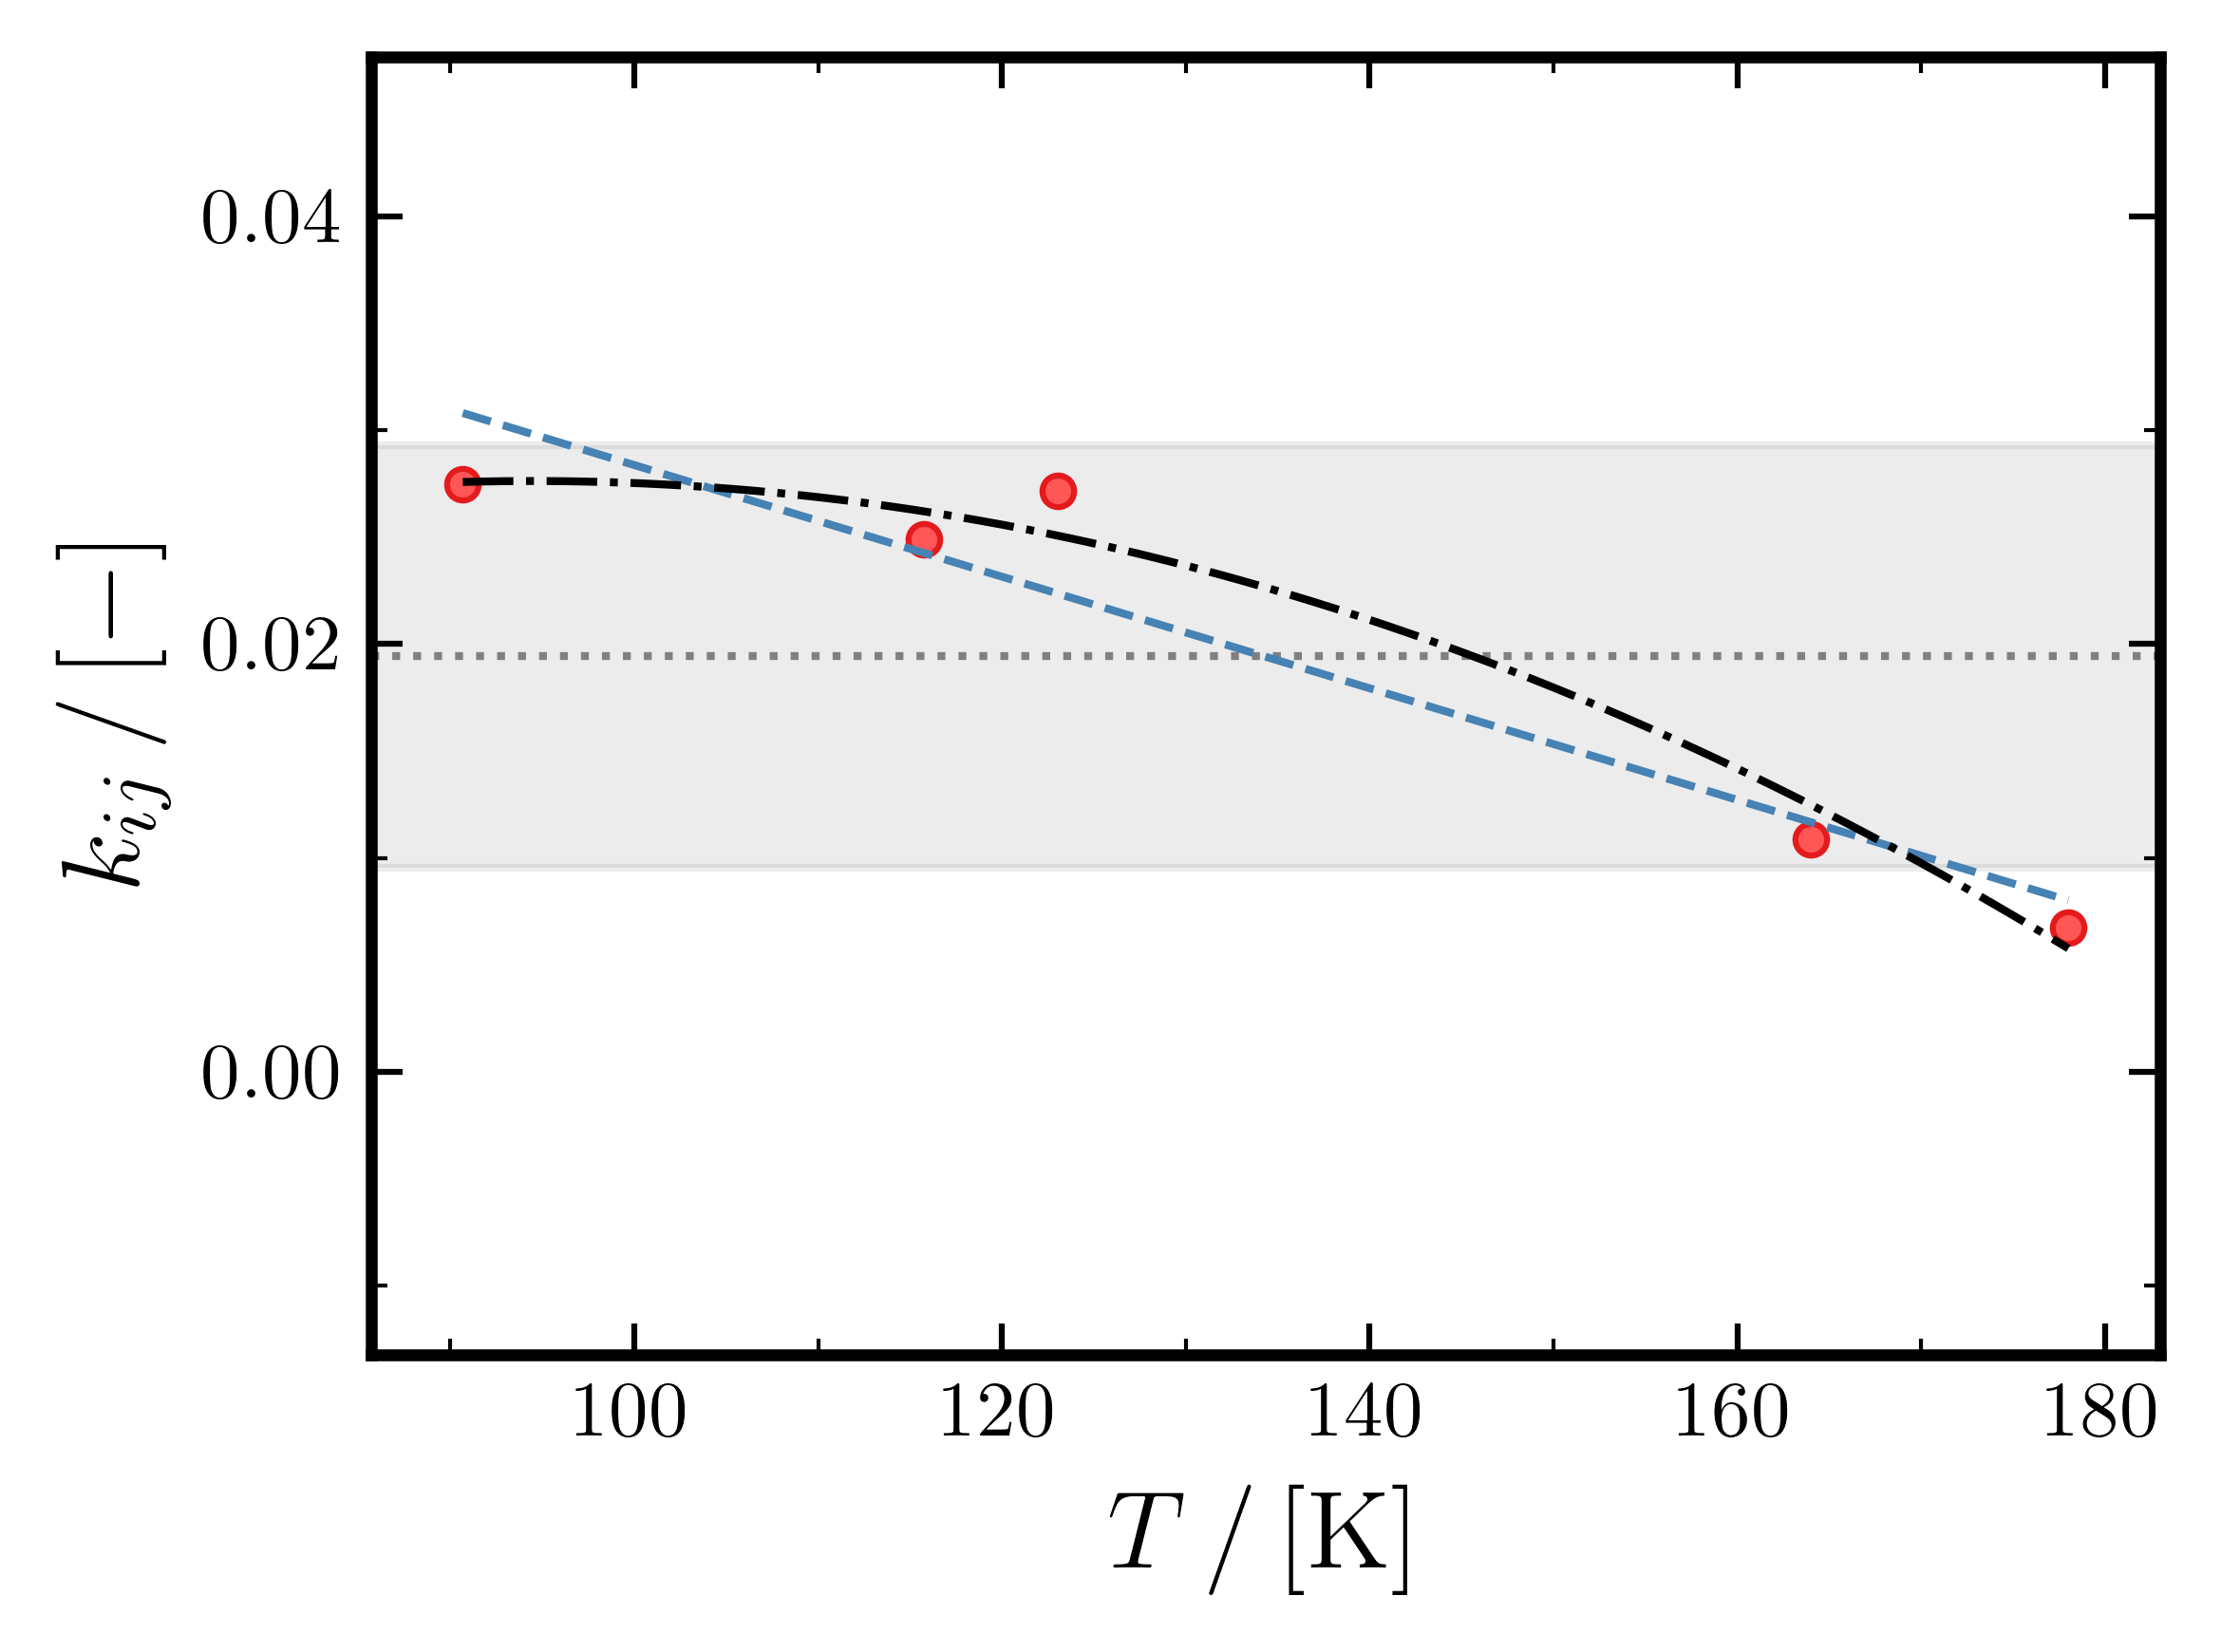

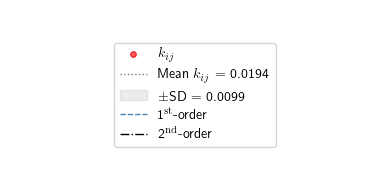

In [14]:
T_fit           = np.linspace(T_data.min(), T_data.max(), nfit)
kij_fit_lin     = kij_func_lin(T_fit)
kij_fit_quad    = kij_func_quad(T_fit)

fig1, ax1 = ps.plot_init()

ax1.plot(df_best_kij["Temperature_[K]"], df_best_kij["kij"],linestyle="",
    linewidth=ps.linewidth,marker=ps.markers[0],markersize=ps.markersize, markerfacecolor="#FF5656",
    markeredgewidth=ps.markeredgewidth,color=ps.colors[0],
    label=r"$k_{ij}$")

# Constant: mean and SD as horizontal band
ax1.axhline(kij_mean, color="gray", linewidth=ps.linewidth, linestyle=":",
    label=rf"Mean $k_{{ij}}$ = {kij_mean:.4f}")
ax1.axhspan(kij_mean - kij_std, kij_mean + kij_std,
    alpha=0.15, color="gray",
    label=rf"$\pm$SD = {kij_std:.4f}")

# Linear fit
ax1.plot(T_fit, kij_fit_lin, color="steelblue", linewidth=ps.linewidth, linestyle="--",
    label=r"1$^{\mathrm{st}}$-order")

# Quadratic fit
ax1.plot(T_fit, kij_fit_quad, color="k", linewidth=ps.linewidth, linestyle="-.",
    label=r"2$^{\mathrm{nd}}$-order")
    
ax1.set_xlabel(r"$T\,/\, \mathrm{[K]}$", fontsize=ps.label_fontsize)
ax1.set_ylabel(r"$k_{ij}\, / \, [-]$", fontsize=ps.label_fontsize)
# ps.style_legend(ax1, loc='lower left', ncol=1, borderaxespad=1.0, frame=True)

ax1.minorticks_on()
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax1.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
ax1.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax1.xaxis.set_minor_locator(ticker.MultipleLocator(10))

ax1.set_xlim(T_data.min() - 5, T_data.max() + 5)
ax1.set_ylim(kij_data.min() - 0.02, kij_data.max() + 0.02)

fig1.tight_layout()
ps.save_plot(fig1, f"kij_{mixture.replace('-','-')}_vs_T")
plt.show()

# Separate legend figure
handles, labels = ax1.get_legend_handles_labels()
fig_leg, ax_leg = plt.subplots(figsize=(4, 2))
ax_leg.axis("off")
ax_leg.legend(handles, labels, loc="center", ncol=1, frameon=True)
fig_leg.tight_layout()
ps.save_plot(fig_leg, f"kij_{mixture.replace('-', '-')}_legend")
plt.show()

In [15]:
notebook_end = time.perf_counter()
print(f"Total notebook runtime: {notebook_end - notebook_start:.2f} s")

Total notebook runtime: 12.63 s


In [16]:
out = {
    "T_min": T_min,
    "T_max": T_max,
    "constant": {
        "deg"   : 0,
        "mean"  : kij_mean,
        "std"   : kij_std
    },
    "linear": {
        "deg"   : 1,
        "coeffs": [float(c) for c in coeffs_lin]
    },
    "quadratic": {
        "deg"   : 2,
        "coeffs": [float(c) for c in coeffs_quad]
    },
    "plots": {
        "kij_vs_T" : fig_to_b64(fig1),
        "legend"   : fig_to_b64(fig_leg)
    }
}

Path("KIJ.json").write_text(json.dumps(out, indent=2), encoding="utf-8")

39740